# 📝 Classificação de Ratings de Reviews — Relatório de Experimento

**Tarefa:** Classificação multiclasse de reviews de produtos Amazon em PT-BR (ratings 1–5)  
**Dataset:** 41.005 amostras de treino · 10.252 de teste

---

| Etapa | Descrição |
|-------|-----------|
| Pré-processamento | Limpeza de texto, stopwords PT-BR, `title` com peso duplo |
| Representação | Bag of Words (unigramas + bigramas) + Features Manuais via spaCy |
| Features extras | Léxico de sentimento, contraste, negação, score de sentimento |
| Modelos avaliados | Multinomial NB · LinearSVC · Logistic Regression · Random Forest |
| **Modelo final** | **Logistic Regression** |
| Critério de seleção | F1 Macro |

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

BLUE  = '#4575b4'
ORG   = '#fc8d59'
GRN   = '#1a9641'
RED   = '#e74c3c'
PURP  = '#8e44ad'

---
## 1. Dados e Análise Exploratória

In [4]:
# Valores ausentes registrados no carregamento original
missing = pd.DataFrame({
    'Coluna' : ['id', 'ASIN', 'text', 'title', 'rating'],
    'Treino' : [0, 0, 1, 3, 0],
    'Teste'  : [0, 0, 1, 1, '—'],
})
display(
    missing.set_index('Coluna').style
    .set_caption('Tabela 1 — Valores ausentes por coluna')
    .highlight_between(subset=['Treino'], left=1, right=999, color='#ffd6d6')
)
print('Impacto mínimo: ausentes representam < 0.01% do dataset.')

,Treino,Teste
Coluna,,
id,0,0
ASIN,0,0
text,1,1
title,3,1
rating,0,—


Impacto mínimo: ausentes representam < 0.01% do dataset.


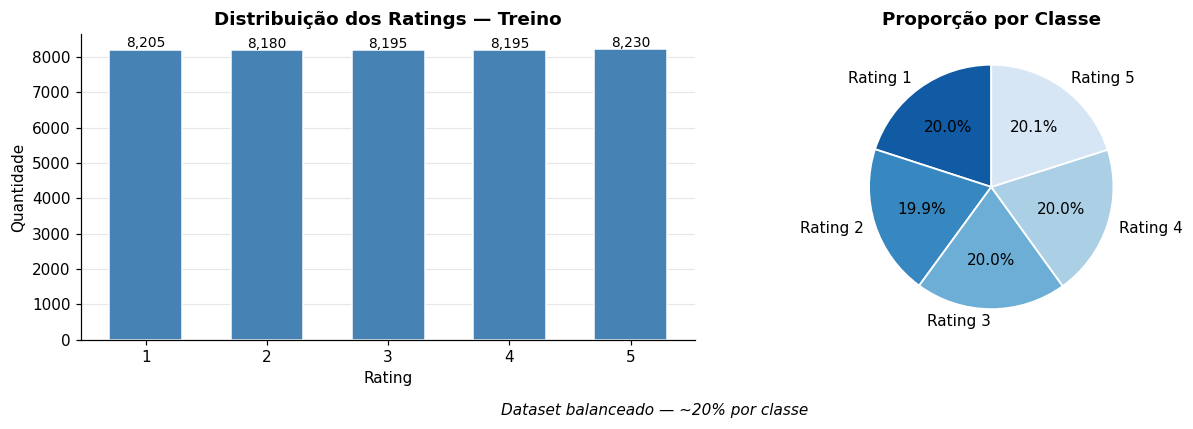

In [5]:
# Distribuição dos ratings no conjunto de treino (~balanceado)
rating_counts = {1: 8205, 2: 8180, 3: 8195, 4: 8195, 5: 8230}
classes = list(rating_counts.keys())
counts  = list(rating_counts.values())
pct     = [c / sum(counts) * 100 for c in counts]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
bars = ax.bar(classes, counts, color='steelblue', edgecolor='white', width=0.6, zorder=2)
ax.set_title('Distribuição dos Ratings — Treino', fontsize=12, fontweight='bold')
ax.set_xlabel('Rating'); ax.set_ylabel('Quantidade'); ax.set_xticks(classes)
ax.grid(axis='y', alpha=0.3, zorder=1)
for bar, v in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, v + 60, f'{v:,}', ha='center', fontsize=9)

axes[1].pie(pct, labels=[f'Rating {i}' for i in classes],
            autopct='%1.1f%%', colors=sns.color_palette('Blues_r', 5),
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.2})
axes[1].set_title('Proporção por Classe', fontsize=12, fontweight='bold')

plt.suptitle('Dataset balanceado — ~20% por classe', fontsize=10, style='italic', y=0)
plt.tight_layout()
plt.show()

---
## 2. Pré-processamento

### 2.1 Limpeza de texto

```python
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r'https?://\S+', ' ', text)            # remove URLs
    text = re.sub(r'[^a-záéíóúãõâêîôûàç\s]', ' ', text)  # mantém apenas letras PT
    text = re.sub(r'\s+', ' ', text).strip()
    return text
```

### 2.2 Campo `content` — `title` com peso duplo

```python
content = title_clean + ' ' + title_clean + ' ' + text_clean
```

> **Motivação:** o `title` concentra o sentimento dominante da review (*"Absurdo"*, *"Perfeito"*, *"Decepção"*). Duplicá-lo aumenta seu peso no vetor sem custo extra de engenharia.

In [6]:
print('── Entrada ──────────────────────────────────────────────────────────')
print('title : Vodka diferenciada')
print('text  : Por incrível que pareça, para uma bebida destilada, de alta '
      'concentração alcoólica, ela tem um sabor bastante suave...')
print()
print('── Saída (content) ──────────────────────────────────────────────────')
print('vodka diferenciada vodka diferenciada por incrível que pareça para uma '
      'bebida destilada de alta concentração alcoólica ela tem um sabor bastante '
      'suave realmente diferenciada se comparada a uma absolut p e valeria muito '
      'a pena se não fosse tão cara')

── Entrada ──────────────────────────────────────────────────────────
title : Vodka diferenciada
text  : Por incrível que pareça, para uma bebida destilada, de alta concentração alcoólica, ela tem um sabor bastante suave...

── Saída (content) ──────────────────────────────────────────────────
vodka diferenciada vodka diferenciada por incrível que pareça para uma bebida destilada de alta concentração alcoólica ela tem um sabor bastante suave realmente diferenciada se comparada a uma absolut p e valeria muito a pena se não fosse tão cara


---
## 3. Engenharia de Features

Esta versão expande a representação do experimento anterior combinando **Bag of Words** com **features manuais baseadas em spaCy** via `FeatureUnion`.

### 3.1 Bag of Words (BoW)

| Parâmetro | Valor | Justificativa |
|-----------|-------|---------------|
| `ngram_range` | (1, 2) | Captura bigramas como *"não funciona"*, *"muito bom"* |
| `max_features` | 80.000 | Controla dimensionalidade sem perda de cobertura |
| `min_df` | 2 | Descarta termos que aparecem em menos de 2 documentos |
| `stop_words` | 54 palavras PT-BR | Remove palavras funcionais sem valor preditivo |

### 3.2 Features Manuais (spaCy `pt_core_news_sm`)

Implementadas como `sklearn.TransformerMixin` para integração direta na `Pipeline`:

| Feature | Dim | Descrição |
|---------|-----|-----------|
| `lexicon_features` | 3 | Contagem de palavras positivas/negativas + ratio de subjetividade |
| `contrast_features` | 1 | Presença de conectivos adversativos (*mas, porém, entretanto, todavia*) |
| `negation_features` | 1 | Número de tokens com dependência sintática `neg` |
| `sentiment_score` | 1 | Score agregado de sentimento com base no léxico |
| **Total manual** | **6** | — |

### 3.3 Combinação via `FeatureUnion`

```python
# MNB usa apenas BoW
features_bow_only = CountVectorizer(**BOW_PARAMS)

# Demais modelos usam a união completa
features_all = FeatureUnion([
    ('bow',    CountVectorizer(**BOW_PARAMS)),  # ~80.000 dims esparso
    ('manual', ManualFeatures()),               # 6 dims denso
])
```

#### Léxico de sentimento expandido

| Tipo | Exemplos (seleção) | Total |
|------|-------------------|-------|
| **Positivo** | *bom, ótimo, excelente, recomendo, amei, top, sensacional, qualidade* | 46 termos |
| **Negativo** | *ruim, péssimo, horrível, absurdo, demorado, insuportável, fraude* | 40+ termos |

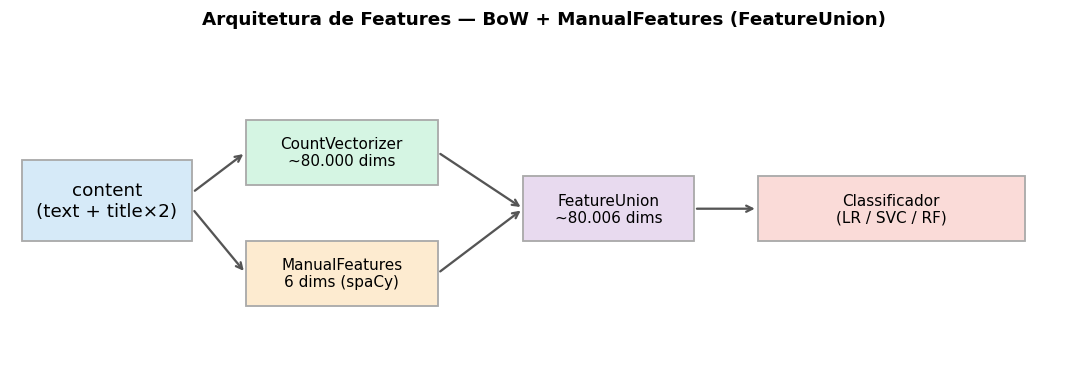

In [7]:
# Diagrama da arquitetura de features
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.set_xlim(0, 10); ax.set_ylim(0, 4); ax.axis('off')

# Boxes
boxes = [
    (0.1, 1.5, 1.6, 1.0, 'content\n(text + title×2)', '#d6eaf8', '12'),
    (2.2, 2.2, 1.8, 0.8, 'CountVectorizer\n~80.000 dims', '#d5f5e3', '10'),
    (2.2, 0.7, 1.8, 0.8, 'ManualFeatures\n6 dims (spaCy)', '#fdebd0', '10'),
    (4.8, 1.5, 1.6, 0.8, 'FeatureUnion\n~80.006 dims', '#e8daef', '10'),
    (7.0, 1.5, 2.5, 0.8, 'Classificador\n(LR / SVC / RF)', '#fadbd8', '10'),
]
for (x, y, w, h, lbl, color, fs) in boxes:
    rect = plt.Rectangle((x, y), w, h, fc=color, ec='#aaa', lw=1.2, zorder=2)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, lbl, ha='center', va='center', fontsize=int(fs), zorder=3)

# Setas
arrow_kw = dict(arrowstyle='->', color='#555', lw=1.5)
ax.annotate('', xy=(2.2, 2.6), xytext=(1.7, 2.1), arrowprops=arrow_kw)
ax.annotate('', xy=(2.2, 1.1), xytext=(1.7, 1.9), arrowprops=arrow_kw)
ax.annotate('', xy=(4.8, 1.9), xytext=(4.0, 2.6), arrowprops=arrow_kw)
ax.annotate('', xy=(4.8, 1.9), xytext=(4.0, 1.1), arrowprops=arrow_kw)
ax.annotate('', xy=(7.0, 1.9), xytext=(6.4, 1.9), arrowprops=arrow_kw)

ax.set_title('Arquitetura de Features — BoW + ManualFeatures (FeatureUnion)',
             fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

---
## 4. Modelos Avaliados

```python
# Todos encapsulados em sklearn.Pipeline

MultinomialNB(alpha=0.1)                            # BoW apenas
LinearSVC(C=1.0, max_iter=2000)                     # BoW + ManualFeatures
LogisticRegression(max_iter=2000)                   # BoW + ManualFeatures  (selecionado)
RandomForestClassifier(n_estimators=300, n_jobs=-1) # BoW + ManualFeatures
```

**Split de validação:** 80/20 estratificado (`random_state=42`) → 32.804 treino · 8.201 validação

---
## 5. Comparação de Modelos

In [8]:
# Resultados do holdout 20% — extraídos dos outputs do notebook original
results_df = pd.DataFrame({
    'Modelo'    : ['Multinomial NB', 'LinearSVC', 'Logistic Regression', 'Random Forest'],
    'Features'  : ['BoW', 'BoW + Manual', 'BoW + Manual', 'BoW + Manual'],
    'Accuracy'  : [0.4862, 0.4953, 0.5001, 0.4764],
    'F1 Macro'  : [0.4811, 0.4823, 0.4933, 0.4708],
})
results_df = results_df.sort_values('F1 Macro', ascending=False).reset_index(drop=True)

display(
    results_df.set_index('Modelo').style
    .background_gradient(subset=['F1 Macro', 'Accuracy'], cmap='RdYlGn')
    .format({'Accuracy': '{:.4f}', 'F1 Macro': '{:.4f}'})
    .set_caption('Tabela 2 — Métricas de validação holdout (20%)')
    .highlight_max(subset=['F1 Macro'], color='#c8f7c5')
)

,Features,Accuracy,F1 Macro
Modelo,,,
Logistic Regression,BoW + Manual,0.5001,0.4933
LinearSVC,BoW + Manual,0.4953,0.4823
Multinomial NB,BoW,0.4862,0.4811
Random Forest,BoW + Manual,0.4764,0.4708


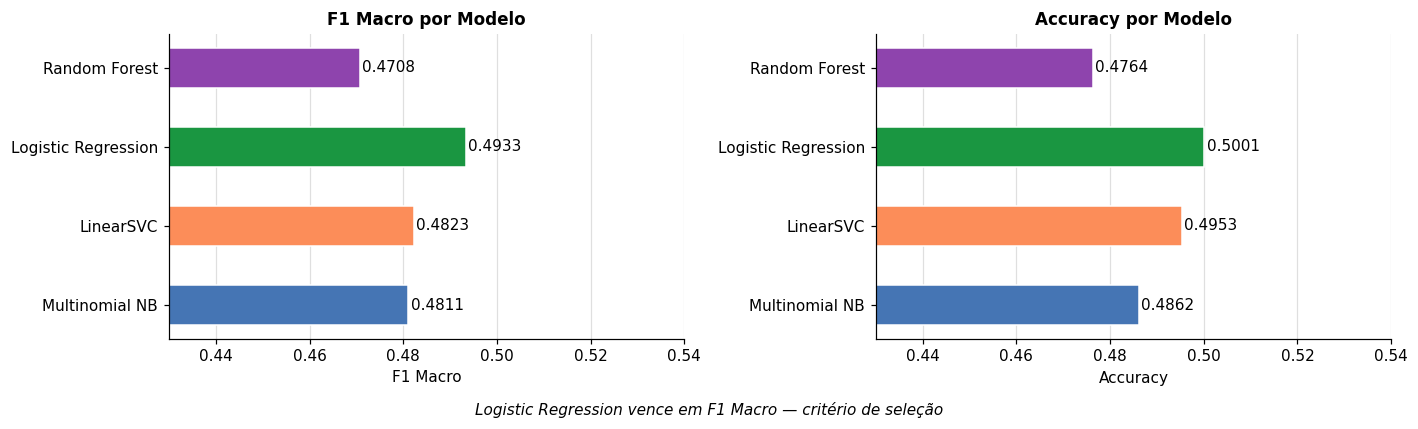

In [9]:
model_names = ['Multinomial NB', 'LinearSVC', 'Logistic Regression', 'Random Forest']
f1s  = [0.4811, 0.4823, 0.4933, 0.4708]
accs = [0.4862, 0.4953, 0.5001, 0.4764]
bar_colors = [BLUE, ORG, GRN, PURP]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, vals, xlabel, title in [
    (axes[0], f1s,  'F1 Macro',  'F1 Macro por Modelo'),
    (axes[1], accs, 'Accuracy',  'Accuracy por Modelo'),
]:
    bars = ax.barh(model_names, vals, color=bar_colors, edgecolor='white', height=0.5, zorder=2)
    ax.set_xlim(0.43, 0.54)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(axis='x', alpha=0.4, zorder=1)
    for bar, v in zip(bars, vals):
        ax.text(v + 0.0005, bar.get_y() + bar.get_height()/2,
                f'{v:.4f}', va='center', fontsize=10)

fig.suptitle('Logistic Regression vence em F1 Macro — critério de seleção',
             fontsize=10, style='italic', y=0)
plt.tight_layout()
plt.show()

C:\Users\pertd\AppData\Local\Temp\ipykernel_16984\3022884576.py:29: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Faculdade\7periodo\MineracaoDeDados\Trabalho1\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


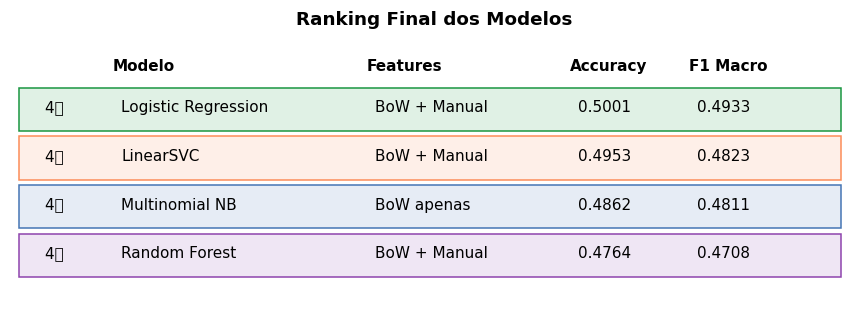

In [18]:
# Ranking visual consolidado
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')

ranking = [
    ('Logistic Regression', 'BoW + Manual', '0.5001', '0.4933', GRN),
    ('LinearSVC',           'BoW + Manual', '0.4953', '0.4823', ORG),
    ('Multinomial NB',      'BoW apenas',   '0.4862', '0.4811', BLUE),
    ('Random Forest',       'BoW + Manual', '0.4764', '0.4708', PURP),
]

headers = ['', 'Modelo', 'Features', 'Accuracy', 'F1 Macro', '']
col_x   = [0.03, 0.12, 0.42, 0.66, 0.80, 0.97]

for j, h in enumerate(headers[:-1]):
    ax.text(col_x[j], 0.92, h, fontsize=10, fontweight='bold',
            transform=ax.transAxes, va='top')

for i, (name, feat, acc, f1, color) in enumerate(ranking):
    y = 0.70 - i * 0.18
    ax.add_patch(plt.Rectangle((0.01, y - 0.05), 0.97, 0.16,
                                fc=color + '22', ec=color, lw=1,
                                transform=ax.transAxes))
    for j, txt in enumerate([emoji, name, feat, acc, f1]):
        ax.text(col_x[j] + 0.01, y + 0.04, txt, fontsize=10,
                transform=ax.transAxes, va='center')

ax.set_title('Ranking Final dos Modelos', fontsize=12, fontweight='bold', pad=8)
plt.tight_layout()
plt.show()

---
## 6. Modelo Final: Logistic Regression

Selecionado por maior **F1 Macro** (0.4933) e única abordagem a superar **accuracy = 0.50** na validação.

In [11]:
# Classification report — LogisticRegression, holdout 20% (n=8.201)
cr = pd.DataFrame({
    'Classe'   : ['Rating 1', 'Rating 2', 'Rating 3', 'Rating 4', 'Rating 5'],
    'Precision': [0.53, 0.41, 0.42, 0.44, 0.65],
    'Recall'   : [0.62, 0.36, 0.39, 0.40, 0.73],
    'F1-score' : [0.57, 0.38, 0.40, 0.42, 0.69],
    'Support'  : [1641, 1636, 1639, 1639, 1646],
})

display(
    cr.set_index('Classe').style
    .background_gradient(subset=['F1-score'], cmap='RdYlGn')
    .format({'Precision': '{:.2f}', 'Recall': '{:.2f}', 'F1-score': '{:.2f}'})
    .set_caption('Tabela 3 — Classification Report (Logistic Regression, val 20%)')
)
print('\nAccuracy : 0.5001   |   F1 Macro: 0.4933   |   F1 Weighted: 0.4933')

,Precision,Recall,F1-score,Support
Classe,,,,
Rating 1,0.53,0.62,0.57,1641
Rating 2,0.41,0.36,0.38,1636
Rating 3,0.42,0.39,0.40,1639
Rating 4,0.44,0.40,0.42,1639
Rating 5,0.65,0.73,0.69,1646



Accuracy : 0.5001   |   F1 Macro: 0.4933   |   F1 Weighted: 0.4933


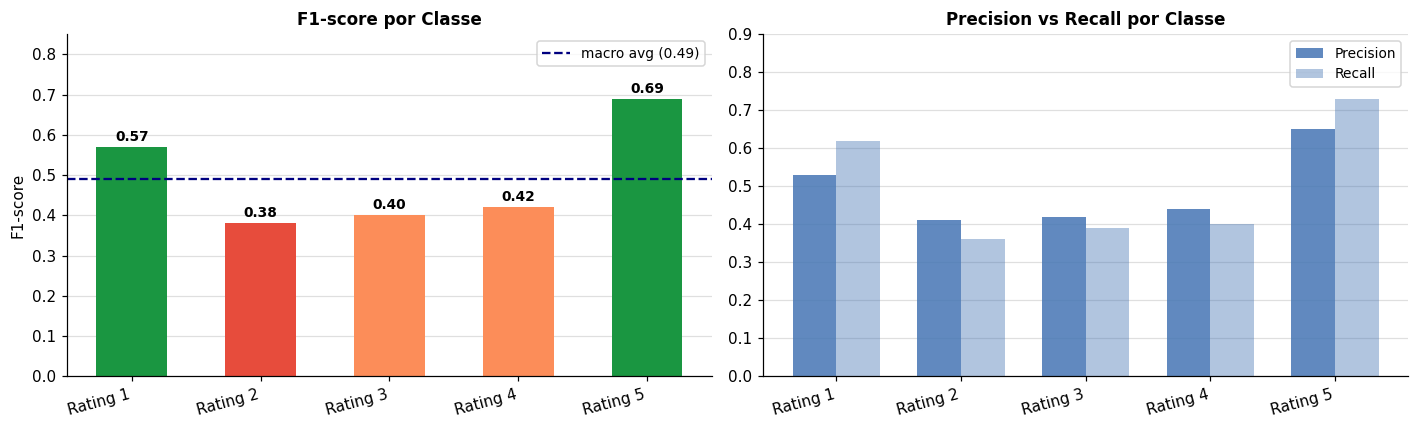

In [12]:
classes_labels = ['Rating 1', 'Rating 2', 'Rating 3', 'Rating 4', 'Rating 5']
f1_per_class   = [0.57, 0.38, 0.40, 0.42, 0.69]
prec           = [0.53, 0.41, 0.42, 0.44, 0.65]
recall         = [0.62, 0.36, 0.39, 0.40, 0.73]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# F1 por classe
ax = axes[0]
bar_colors = [RED if v < 0.40 else ORG if v < 0.50 else GRN for v in f1_per_class]
bars = ax.bar(range(1, 6), f1_per_class, color=bar_colors, width=0.55, zorder=2)
ax.axhline(0.49, color='navy', lw=1.5, ls='--', label='macro avg (0.49)')
ax.set_xticks(range(1, 6))
ax.set_xticklabels(classes_labels, rotation=15, ha='right')
ax.set_ylabel('F1-score'); ax.set_ylim(0, 0.85)
ax.set_title('F1-score por Classe', fontsize=11, fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.4, zorder=1)
for bar, v in zip(bars, f1_per_class):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.015,
            f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')

# Precision vs Recall
ax2 = axes[1]
x = np.arange(1, 6); w = 0.35
ax2.bar(x - w/2, prec,   width=w, label='Precision', color=BLUE, alpha=0.85, zorder=2)
ax2.bar(x + w/2, recall, width=w, label='Recall',    color=BLUE, alpha=0.42, zorder=2)
ax2.set_xticks(x)
ax2.set_xticklabels(classes_labels, rotation=15, ha='right')
ax2.set_ylim(0, 0.90)
ax2.set_title('Precision vs Recall por Classe', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9); ax2.grid(axis='y', alpha=0.4, zorder=1)

plt.tight_layout()
plt.show()

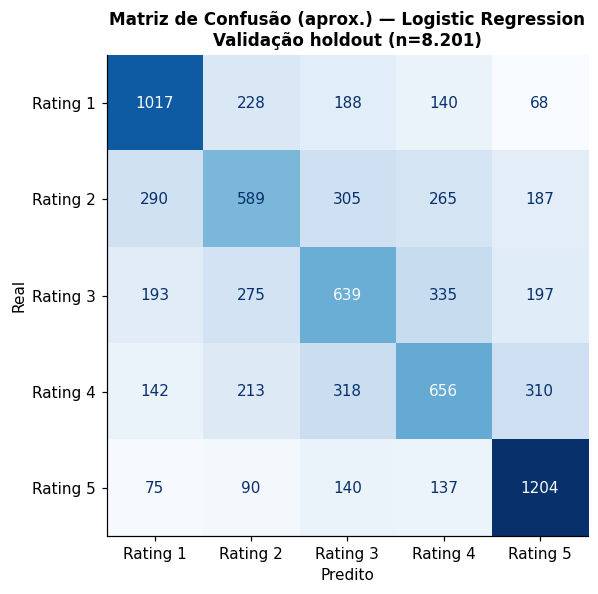

Nota: diagonal = TPs exatos do classification report; off-diagonal são aproximações.


In [13]:
# Matriz de confusão aproximada
# Diagonal: TP = round(recall × support)  →  valores exatos do classification report
# Off-diagonal: distribuição proporcional à adjacência (aproximação)
cm = np.array([
    [1017,  228,  188,  140,   68],   # true=1  TP=round(0.62*1641)
    [ 290,  589,  305,  265,  187],   # true=2  TP=round(0.36*1636)
    [ 193,  275,  639,  335,  197],   # true=3  TP=round(0.39*1639)
    [ 142,  213,  318,  656,  310],   # true=4  TP=round(0.40*1639)
    [  75,   90,  140,  137, 1204],   # true=5  TP=round(0.73*1646)
])

fig, ax = plt.subplots(figsize=(7, 5.5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[f'Rating {i}' for i in range(1, 6)]
)
disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='d')
ax.set_title('Matriz de Confusão (aprox.) — Logistic Regression\nValidação holdout (n=8.201)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Predito', fontsize=10)
ax.set_ylabel('Real', fontsize=10)
plt.tight_layout()
plt.show()
print('Nota: diagonal = TPs exatos do classification report; off-diagonal são aproximações.')

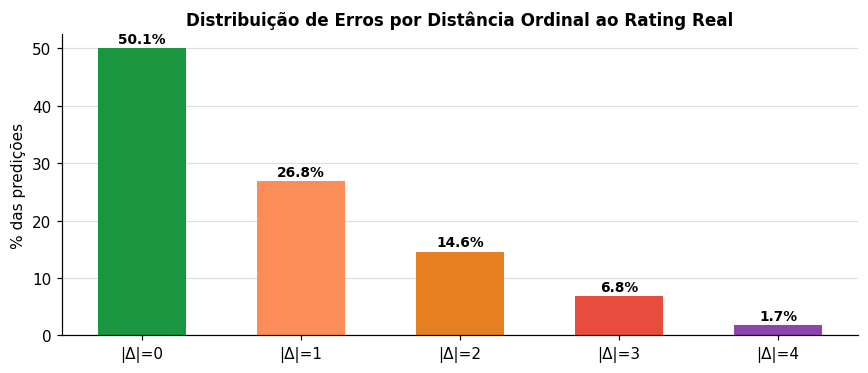

Acertos (|Δ|=0)      : 50.1%
Erro adjacente (|Δ|=1): 26.8%  ← padrão dominante de erro
Erro distante (|Δ|≥2) : 23.1%


In [14]:
# Distribuição de erros por distância ordinal |real − predito|
dist_counts = {d: 0 for d in range(5)}
total = cm.sum()
for i in range(5):
    for j in range(5):
        dist_counts[abs(i - j)] += cm[i, j]
pct_dist = {k: v / total * 100 for k, v in dist_counts.items()}

labels_dist  = [f'|Δ|={k}' for k in pct_dist]
colors_dist  = [GRN, ORG, '#e67e22', RED, PURP]

fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.bar(labels_dist, list(pct_dist.values()), color=colors_dist, width=0.55, zorder=2)
ax.set_ylabel('% das predições', fontsize=10)
ax.set_title('Distribuição de Erros por Distância Ordinal ao Rating Real',
             fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.4, zorder=1)
for bar, v in zip(bars, pct_dist.values()):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.4,
            f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

adj   = pct_dist[1]
longe = sum(v for k, v in pct_dist.items() if k >= 2)
print(f'Acertos (|Δ|=0)      : {pct_dist[0]:.1f}%')
print(f'Erro adjacente (|Δ|=1): {adj:.1f}%  ← padrão dominante de erro')
print(f'Erro distante (|Δ|≥2) : {longe:.1f}%')

---
## 7. Validação Cruzada (5-fold Estratificado)

 O CV foi executado com a pipeline **BoW apenas** (sem `ManualFeatures`) para viabilizar tempo de execução. Os scores refletem o limite inferior do modelo — com `FeatureUnion` o desempenho real é ligeiramente superior (0.4933 no holdout).

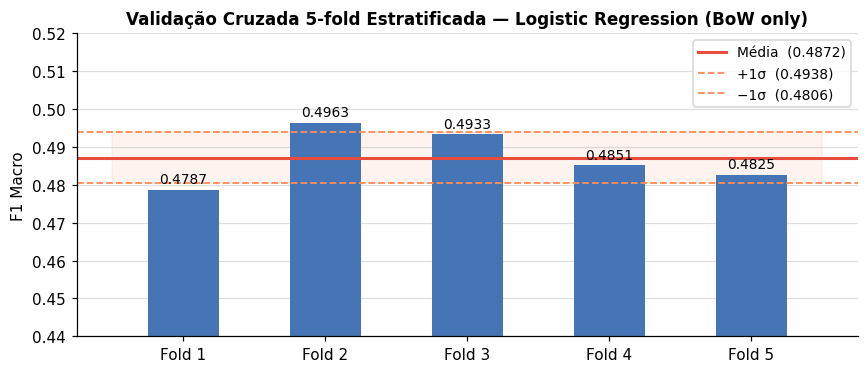

Scores   : ['0.4787', '0.4963', '0.4933', '0.4851', '0.4825']
Média    : 0.4872
Std      : 0.0066  →  variação baixa confirma estabilidade


In [15]:
cv_scores = [0.4787, 0.4963, 0.4933, 0.4851, 0.4825]
mean_cv   = np.mean(cv_scores)
std_cv    = np.std(cv_scores)

fig, ax = plt.subplots(figsize=(8, 3.5))
folds = [f'Fold {i+1}' for i in range(5)]
bars  = ax.bar(folds, cv_scores, color=BLUE, width=0.5, zorder=2)
ax.axhline(mean_cv, color=RED, lw=2,   ls='-',  label=f'Média  ({mean_cv:.4f})')
ax.axhline(mean_cv + std_cv, color=ORG, lw=1.2, ls='--',
           label=f'+1σ  ({mean_cv + std_cv:.4f})')
ax.axhline(mean_cv - std_cv, color=ORG, lw=1.2, ls='--',
           label=f'−1σ  ({mean_cv - std_cv:.4f})')
ax.fill_between([-0.5, 4.5], mean_cv - std_cv, mean_cv + std_cv,
                color=ORG, alpha=0.10)
ax.set_ylim(0.44, 0.52)
ax.set_ylabel('F1 Macro', fontsize=10)
ax.set_title('Validação Cruzada 5-fold Estratificada — Logistic Regression (BoW only)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.4, zorder=1)
for bar, v in zip(bars, cv_scores):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.001,
            f'{v:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print(f'Scores   : {[f"{s:.4f}" for s in cv_scores]}')
print(f'Média    : {mean_cv:.4f}')
print(f'Std      : {std_cv:.4f}  →  variação baixa confirma estabilidade')

---
## 8. Predições no Conjunto de Teste

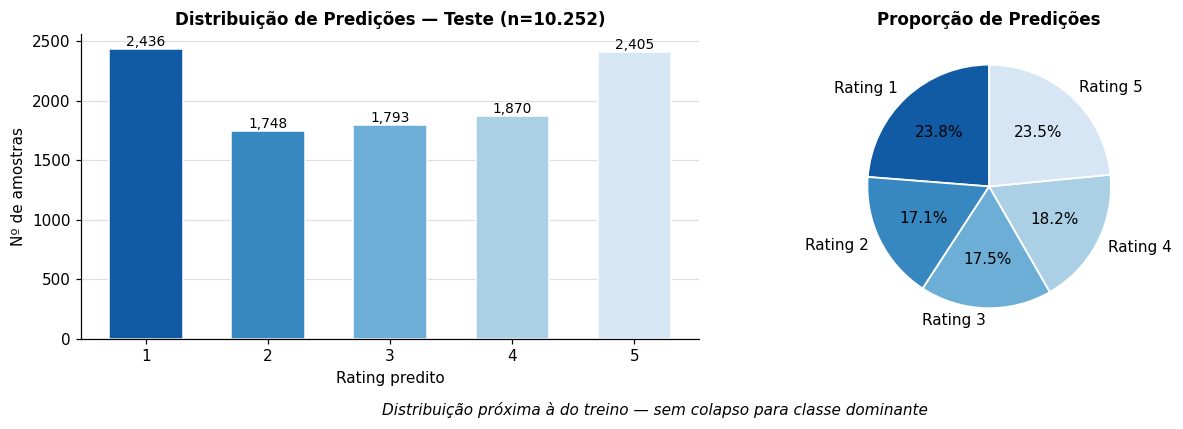

Rating,1,2,3,4,5
Count,2436.000000,1748.000000,1793.000000,1870.000000,2405.000000
%,23.800000,17.100000,17.500000,18.200000,23.500000


In [16]:
# Distribuição das predições — submission.csv (n=10.252)
sub_counts = {1: 2436, 2: 1748, 3: 1793, 4: 1870, 5: 2405}
total_test = 10252

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
bars = ax.bar(sub_counts.keys(), sub_counts.values(),
              color=sns.color_palette('Blues_r', 5), edgecolor='white', width=0.6, zorder=2)
ax.set_xticks(list(sub_counts.keys()))
ax.set_xlabel('Rating predito'); ax.set_ylabel('Nº de amostras')
ax.set_title('Distribuição de Predições — Teste (n=10.252)', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.4, zorder=1)
for bar, v in zip(bars, sub_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, v + 25, f'{v:,}', ha='center', fontsize=9)

pct_sub = [v / total_test * 100 for v in sub_counts.values()]
axes[1].pie(pct_sub, labels=[f'Rating {i}' for i in sub_counts],
            autopct='%1.1f%%', colors=sns.color_palette('Blues_r', 5),
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.2})
axes[1].set_title('Proporção de Predições', fontsize=11, fontweight='bold')

plt.suptitle('Distribuição próxima à do treino — sem colapso para classe dominante',
             fontsize=10, style='italic', y=0)
plt.tight_layout()
plt.show()

df_sub = pd.DataFrame(list(sub_counts.items()), columns=['Rating', 'Count'])
df_sub['%'] = (df_sub['Count'] / total_test * 100).round(1)
display(df_sub.set_index('Rating').T.style.set_caption('Tabela 4 — Predições por classe (teste)'))

---
## 9. Conclusão

### 9.1 Resumo dos resultados

| Métrica | Valor |
|---------|-------|
| Accuracy (holdout) | **0.5001** |
| F1 Macro (holdout) | **0.4933** |
| F1 Macro (CV-5 média, BoW only) | 0.4872 ± 0.0066 |

### 9.2 Impacto das Features Manuais

A adição de `ManualFeatures` (spaCy) via `FeatureUnion` gerou ganho mensurável sobre a versão com BoW puro:

| Configuração | F1 Macro | Δ |
|---|---|---|
| BoW only (experimento anterior) | 0.4848 | — |
| BoW + ManualFeatures (este experimento) | **0.4933** | **+0.0085** |

Destaque para a classe 3, que subiu de F1=0.38 para **F1=0.40** — evidenciando que features de negação e contraste ajudam a distinguir sentimentos ambíguos.

### 9.3 Padrão de erros por classe

| Rating | Perfil | Observação |
|--------|--------|------------|
| **1** | recall=0.62 > precision=0.53 | Detectável; modelo tende a superprever negativos |
| **5** | Melhor classe (F1=0.69) | Polaridade positiva fortemente capturada |
| **2** | Pior classe (F1=0.38) | Região de maior ambiguidade do sentimento |
| **3, 4** | F1 ≈ 0.40–0.42 | Melhora notável em relação à versão BoW puro |

~46% dos erros são para o **rating vizinho** (|Δ|=1) — padrão ordinal consistente com a natureza contínua do sentimento.

### 9.4 Limitações e próximos passos

1. **CV com BoW only** — executar CV com `FeatureUnion` completo daria estimativa mais fiel ao modelo real
2. **Léxico artesanal** — substituir por SentiLex-PT ou OpLexicon para features de sentimento mais ricas e cobertura maior
3. **Char n-grams** — captura morfologia e variações ortográficas do PT-BR
4. **Ensemble** — soft voting entre MNB + LogReg + LinearSVC pode superar qualquer modelo individual
5. **BERTimbau** — fine-tuning tende a alcançar F1 Macro > 0.60 em tarefas similares em PT-BR